# Overlapping Dataset

In [19]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
save_path = "/project2/cdonnat/sleepstages/data/overlapping/overlapping_data.pt"
data_list = torch.load(save_path, weights_only=False)

In [17]:
rows = []
for d in data_list:
    row = {
        "y": d["y"].item(),
        "c": d["c"].numpy(),
        **d["metadata"]
    }
    rows.append(row)

df = pd.DataFrame(rows)

In [22]:
df.columns

Index(['y', 'c', 'id', 'patient', 'segment'], dtype='object')

## Labels & Individuals

In [30]:
print(len(df))
print(len(df["c"].iloc[0]))
df["patient"].value_counts().sort_index()

103248
294


patient
20080514TT    1434
20080519MH    1434
20080521AK    1434
20080528SW    1434
20080617AB    1434
              ... 
20100325SE    1434
20100326SL    1434
20100420SN    1434
20101011FB    1434
20110221AK    1434
Name: count, Length: 72, dtype: int64

1434 snapshots per each of the 72 patients for a total of 103248 snapshots of size 294x294. 

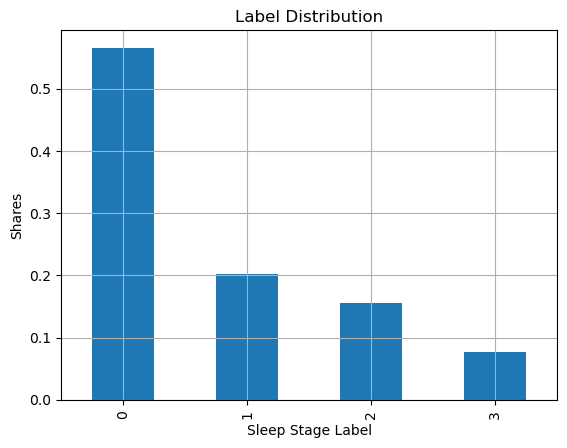

In [21]:
label_counts = df["y"].value_counts(9).sort_index()

plt.figure()
label_counts.plot(kind="bar")
plt.xlabel("Sleep Stage Label")
plt.ylabel("Shares")
plt.title("Label Distribution")
plt.grid(True)
plt.show()

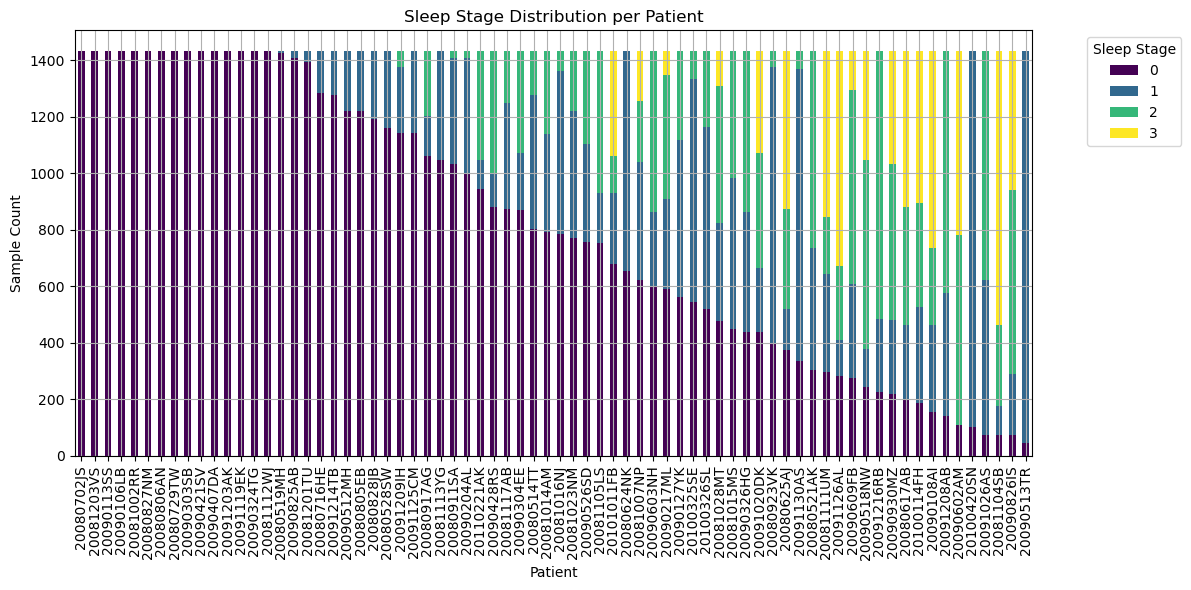

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

# Compute counts per patient per stage
counts = df.groupby(['patient', 'y']).size().unstack(fill_value=0)

# Sort patients by class 0 
if 0 in counts.columns:
    counts = counts.sort_values(by=0, ascending=False)
else:
    print("Warning: No class '0' found. Skipping sort.")

class_order = sorted(counts.columns)
counts = counts[class_order]

# Plot 
counts.plot(kind='bar', stacked=True, figsize=(12, 6), colormap="viridis")
plt.xlabel("Patient")
plt.ylabel("Sample Count")
plt.title("Sleep Stage Distribution per Patient")
plt.legend(title="Sleep Stage", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()


## Correlation Values

## Baseline

In [33]:
import torch
import numpy as np
import pandas as pd

def flatten_lower(corr):
    """
    Extracts the strictly lower-triangular part of a square matrix (corr),
    flattens it into a 1D numpy vector, and returns it.
    """
    # Convert to numpy if it's a tensor
    mat = corr.numpy() if isinstance(corr, torch.Tensor) else corr
    # Get indices for lower triangle excluding diagonal
    i_lower = np.tril_indices(mat.shape[0], k=-1)
    return mat[i_lower]

# Assume data_list is already loaded and has dicts with 'c', 'y', and 'metadata'
records = []
for d in data_list:
    vec = flatten_lower(d['c'])
    label = int(d['y'].item()) if isinstance(d['y'], torch.Tensor) else int(d['y'])
    patient = d['metadata']['patient']
    records.append({
        "x": vec,
        "y": label,
        "patient": patient
    })

# Create DataFrame
da = pd.DataFrame(records)


In [35]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

# Assume 'da' DataFrame with columns 'x', 'y', 'patient' is already in scope

# Split patients into train/test ensuring no patient spillover
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(da, groups=da['patient']))

train_da = da.iloc[train_idx].reset_index(drop=True)
test_da = da.iloc[test_idx].reset_index(drop=True)

# Compute and display class distributions
train_dist = train_da['y'].value_counts(normalize=True).sort_index()
test_dist = test_da['y'].value_counts(normalize=True).sort_index()

dist_df = pd.DataFrame({
    'train': train_dist,
    'test': test_dist
})

# Verify no patient overlap
assert set(train_da['patient']).isdisjoint(set(test_da['patient'])), "Patient spillover detected"

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

# Prepare feature and label arrays
X_train = np.stack(train_da['x'].values)
y_train = train_da['y'].values
X_test  = np.stack(test_da ['x'].values)
y_test  = test_da ['y'].values

# Train multinomial logistic regression
clf = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Compute metrics
acc           = accuracy_score(y_test, y_pred)
balanced_acc  = balanced_accuracy_score(y_test, y_pred)

print(f"Accuracy:          {acc:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")

# Plot confusion matrix
disp = ConfusionMatrixDisplay.from_estimator(
    clf, X_test, y_test, 
    display_labels=clf.classes_,
    cmap=plt.cm.Blues,
    normalize=None
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, digits=4))
